# Exponential Smoothing in State Space Form with `numpyro_forecast`

Exponential smoothing is one of the most widely used forecasting
techniques. In its classical (component) form it is a set of recursive
update equations for a *level*, a *trend*, and a *seasonal* component. A
more powerful way to write the same idea is the **innovations state
space form** (also known as the single source of error, or SSOE, model),
which turns exponential smoothing into a proper generative stochastic
process. The key consequence is that forecast uncertainty is propagated
correctly: the prediction interval widens with the horizon instead of
collapsing to the observation noise.

This notebook ports the blog post [*Exponential Smoothing with NumPyro:
State Space
Form*](https://juanitorduz.github.io/exponential_smoothing_numpyro_ssm/)
(with material from its predecessor [*Notes on Exponential Smoothing
with
NumPyro*](https://juanitorduz.github.io/exponential_smoothing_numpyro/))
into a `numpyro_forecast` example. We show how to write the damped
Holt-Winters model in state space form as a plain NumPyro model on the
package’s
[`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html)
building block (the single-source-of-error recursion is exactly what the
block implements), fit it with the NUTS sampler, and reuse the package’s
forecasting and evaluation machinery. Along the way we introduce the JAX
`scan` operation that rolls the latent state forward.

A practical note on the design: the
[`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html)
and
[`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html)
building blocks assume a deterministic mean plus independent per-step
noise, which is not how an innovations model behaves: the error of one
step drives the state of the next. That error feedback is what `ssoe`
provides. It takes the driving series as an argument, and because the
package’s `predict_in_sample` and `to_datatree` call the model with
`data=None`, the observed series has to travel through the `covariates`
argument; the model reads only its first `t_obs` rows, which the block
checks.

## Prepare notebook

In [1]:
import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import preliz as pz
import xarray as xr
from jax import random
from numpyro.infer import MCMC, NUTS

from numpyro_forecast import (
    Horizon,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    predictions_to_datatree,
    ssoe,
    to_datatree,
)
from numpyro_forecast.arrays import concat_future
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/numpyro_forecast/.claude/worktrees/refactor3-pr-e1/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.claude/worktrees/refactor3-pr-e1/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")

## Generate synthetic data

We use the same synthetic series as the source posts: a seasonal cosine
wave with period $m = 15$, a slow logarithmic trend, and additive
Gaussian noise,

$$y_t = \cos(2 \pi t) + \log(t + 1) + 0.2 \, \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, 1).$$

This gives us a trend, a clear seasonality, and enough noise to make the
inference interesting. We hold out the last $20\%$ of the series as a
test set.

In [2]:
n_seasons = 15
t = jnp.linspace(0, n_seasons + 1, (n_seasons + 1) * n_seasons)

rng_key, rng_subkey = random.split(rng_key)
y = jnp.cos(2 * jnp.pi * t) + jnp.log(t + 1) + 0.2 * random.normal(rng_subkey, t.shape)

n = y.shape[0]
n_train = int(0.8 * n)
future = n - n_train

t_train, t_test = t[:n_train], t[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# The package expects time at axis -2 and the observation dimension at axis -1.
train_data = y_train[:, None]
test_data = y_test[:, None]

# The observed series doubles as the covariate: the model reads its history from
# here (only the first t_obs rows are ever read), and the trailing zero rows just
# fix the forecast horizon.
covariates_train = train_data
covariates_full = concat_future(train_data, jnp.zeros((future, 1)))

print(f"total: {n}, train: {n_train}, test (forecast horizon): {future}")

total: 240, train: 192, test (forecast horizon): 48

We can visualize the series:

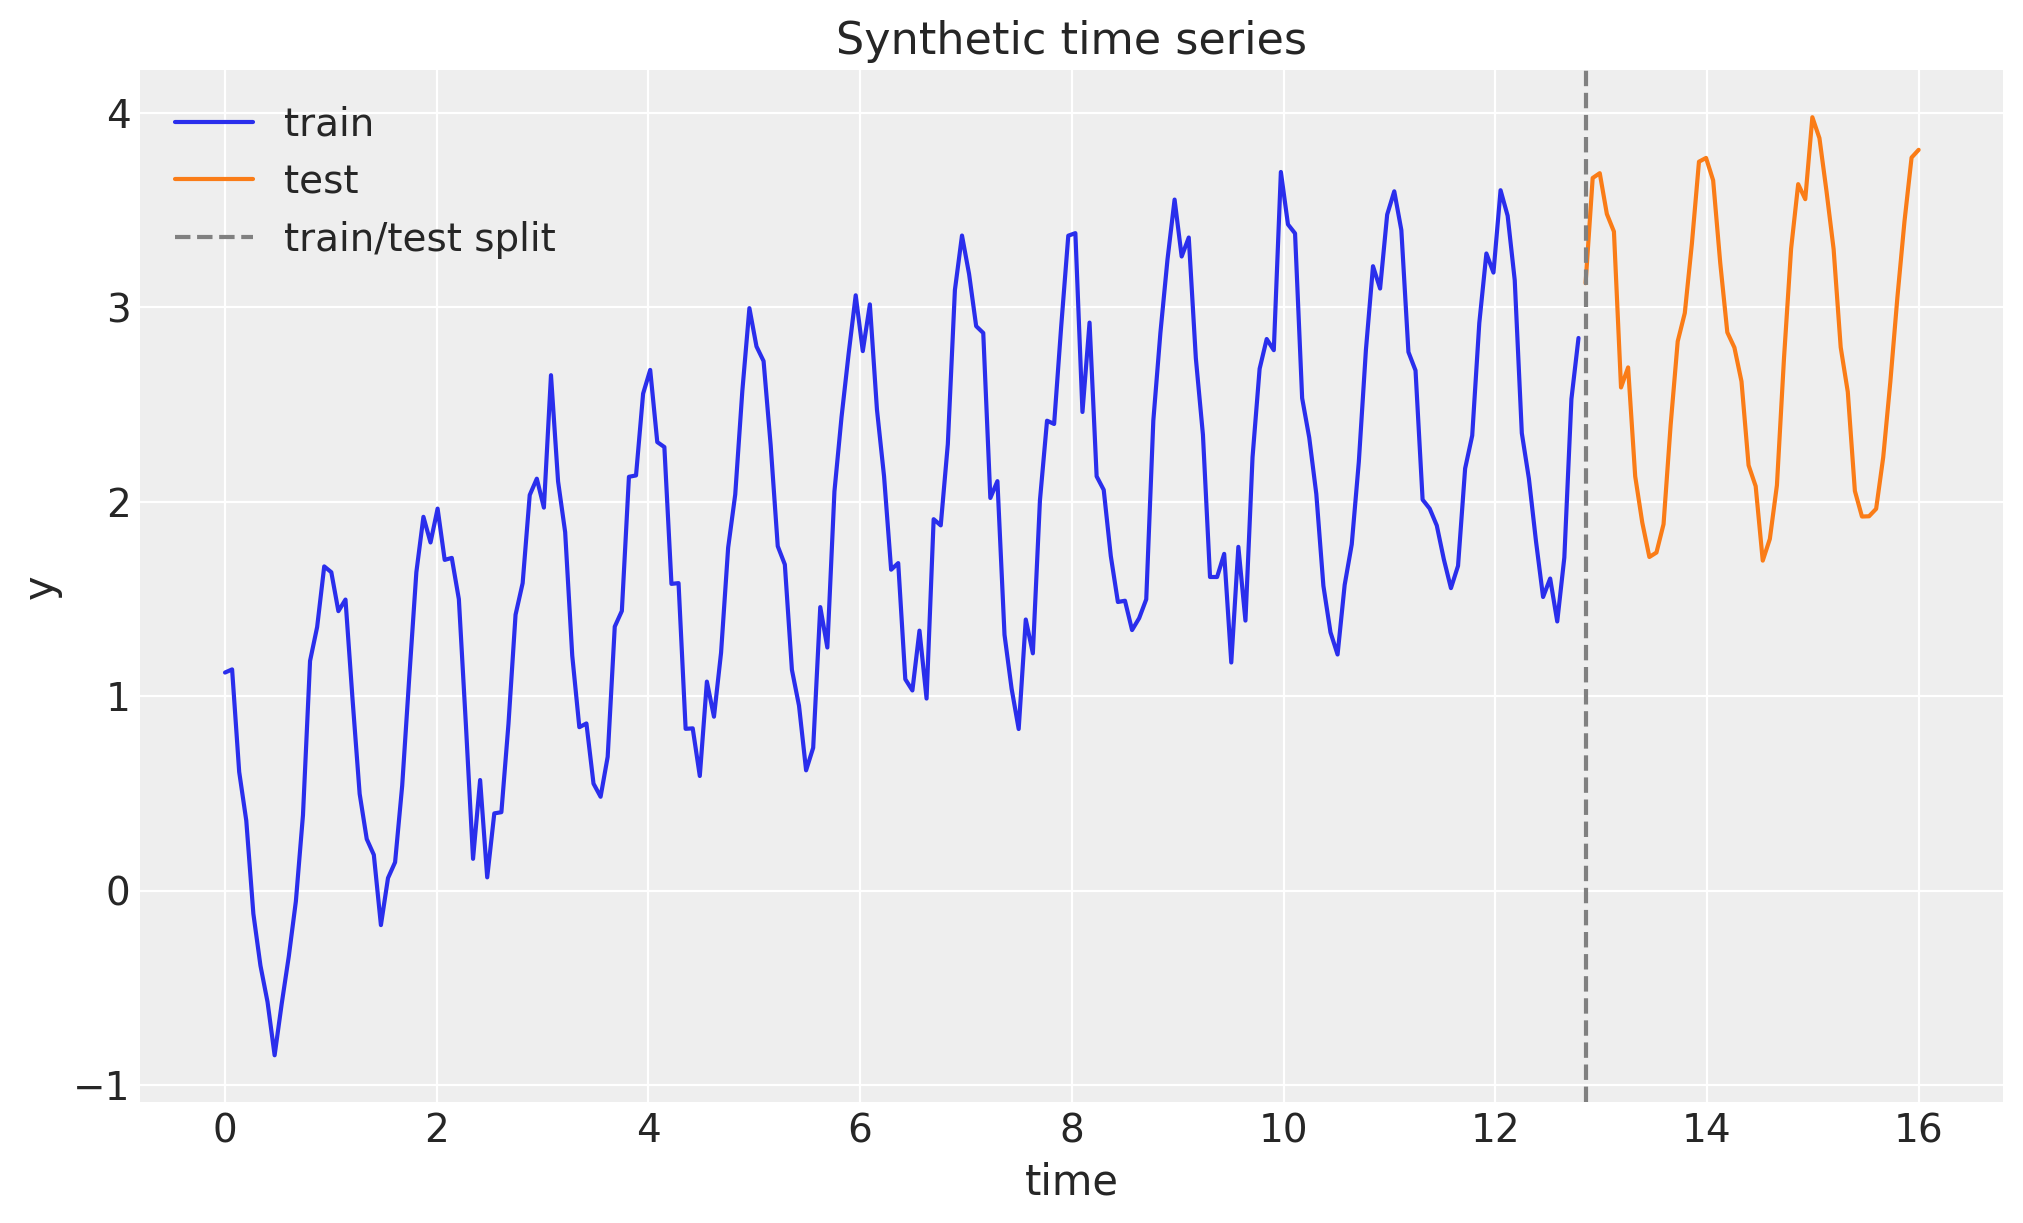

In [3]:
fig, ax = plt.subplots()
ax.plot(t_train, y_train, color="C0", label="train")
ax.plot(t_test, y_test, color="C1", label="test")
ax.axvline(float(t_test[0]), color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Synthetic time series", xlabel="time", ylabel="y");

## A short detour on `scan`

Exponential smoothing is defined by a recursion: each state depends on
the previous one. In JAX we express such recursions with
[`jax.lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
rather than a Python `for` loop, because `scan` compiles to a single
efficient, differentiable operation. Conceptually `scan` is equivalent
to the following pure-Python function (from the JAX documentation):

``` python
def scan(f, init, xs, length=None):
    if xs is None:
        xs = [None] * length
    carry = init
    ys = []
    for x in xs:
        carry, y = f(carry, x)
        ys.append(y)
    return carry, np.stack(ys)
```

It threads a *carry* (the running state) through a step function `f`,
and stacks the per-step outputs. The `ssoe` building block runs two such
scans for us, but the state update it threads through them is ours to
write, so it pays to see the mechanics once.

### A simple example

As a warm-up, we use `scan` to compute the geometric damping sum
$\varphi_h = \varphi + \varphi^2 + \cdots + \varphi^h$ that appears in
the damped-trend forecast formula below. The carry holds the running sum
and the current power of $\varphi$.

In [4]:
def damping_sum(phi, h):
    def step(carry, _):
        running_sum, power = carry
        power = power * phi
        running_sum = running_sum + power
        return (running_sum, power), running_sum

    (total, _), partial_sums = jax.lax.scan(step, (0.0, 1.0), xs=None, length=h)
    return total, partial_sums


phi_example = 0.8
total, partial_sums = damping_sum(phi_example, 5)
closed_form = sum(phi_example**i for i in range(1, 6))
print(f"scan result:  {float(total):.5f}")
print(f"closed form:  {closed_form:.5f}")
print(f"partial sums: {np.asarray(partial_sums).round(5)}")

scan result:  2.68928
closed form:  2.68928
partial sums: [0.8     1.44    1.952   2.3616  2.68928]

## From component form to state space form

The classical **damped Holt-Winters** method with additive seasonality
of period $m$ is a set of recursive updates for the level $\ell_t$, the
trend $b_t$, and the seasonal component $s_t$, together with an $h$-step
forecast,

$$
\begin{align*}
\hat{y}_{t+h \mid t} &= \ell_t + \varphi_h \, b_t + s_{t + h - m(k+1)}, \\
\ell_t &= \alpha (y_t - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + \varphi \, b_{t-1}), \\
b_t &= \beta^{*} (\ell_t - \ell_{t-1}) + (1 - \beta^{*}) \varphi \, b_{t-1}, \\
s_t &= \gamma (y_t - \ell_{t-1} - \varphi \, b_{t-1}) + (1 - \gamma) s_{t-m},
\end{align*}
$$

where $\alpha, \beta^{*}, \gamma \in (0, 1)$ are smoothing parameters,
$\varphi \in (0, 1)$ is the damping factor,
$\varphi_h = \varphi + \varphi^2 + \cdots + \varphi^h$, and
$k = \lfloor (h-1)/m \rfloor$.

The **innovations state space form** (SSOE) rewrites this as a
generative model driven by a *single* error term $\varepsilon_t$ shared
across all equations,

$$
\begin{align*}
y_t &= \underbrace{\ell_{t-1} + \varphi \, b_{t-1} + s_{t-m}}_{\mu_t} + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, \sigma), \\
\ell_t &= \ell_{t-1} + \varphi \, b_{t-1} + \alpha \, \varepsilon_t, \\
b_t &= \varphi \, b_{t-1} + \beta \, \varepsilon_t, \\
s_t &= s_{t-m} + \gamma \, \varepsilon_t,
\end{align*}
$$

with the coefficient map $\beta = \beta^{*} \alpha$ and
$\gamma = \gamma^{*} (1 - \alpha)$. The two forms are mathematically
equivalent, but the SSOE form is the one we want for probabilistic
forecasting. In sample, the innovation is exactly the one-step-ahead
forecast error $\varepsilon_t = y_t - \mu_t$, so the whole state
trajectory is a deterministic function of the observed data and the
parameters. Out of sample there is no data, so $\varepsilon_t$ is
*sampled* and fed back into the level, trend, and seasonal updates.
Because a single innovation drives every component, the forecast
uncertainty compounds and the prediction interval widens with the
horizon, which is the behavior we expect from a genuine stochastic
process.

## The model

The model is a plain NumPyro function `(covariates, data=None)`. Its
first line derives the per-call
[`Horizon`](https://juanitorduz.github.io/numpyro_forecast/reference/models.Horizon.html)
from the shapes (the observed data `h.data`, the number of in-sample
steps `h.t_obs`, and the forecast length `h.future`), and the recursion
goes to the
[`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html)
building block. The block takes the driving series `y` (sliced from the
covariates, see the design note above), the initial state, a `step`
function, and the innovation distribution, and it owns the two scans,
neither of which contains a NumPyro sample site:

1.  **In sample.** A deterministic filter consumes the observed series:
    at each step `step(carry, x_t)` returns the one-step-ahead mean
    $\mu_t$ and a `carry_fn(y_t, eps_t)` that advances the state with
    the innovation $\varepsilon_t = y_t - \mu_t$. The means come back as
    `r.mu`; the whole in-sample likelihood is then a single `Normal`
    observation site `"obs"` against them, and we also expose $\mu_t$ as
    the deterministic site `"mu"` for the in-sample fit plot.
2.  **Out of sample.** When `h.future > 0` the block draws the horizon
    innovations from the prior at a separate `"eps_future"` site (under
    its own `time_future` plate), rolls the state forward from the final
    in-sample state feeding those innovations back through `carry_fn`,
    and returns the trajectory as `r.y_future`, which we register as the
    deterministic `"forecast"` site the package’s `forecast` driver
    reads. Because `"eps_future"` does not exist while training,
    `Predictive` draws it from the prior at forecast time, exactly like
    the built-in `_future` sites.

The state update `advance` is shared by both scans and is the SSOE
update above, one innovation driving level, trend, and seasonality. One
shape convention to know: rows carry the observation axis, so the scalar
state emits a `(1,)` mean (`mu[None]`) and reads the scalar innovation
back out of the `(1,)` error (`eps_t[0]`); the block checks these shapes
so a mismatch fails loudly instead of broadcasting silently.

The priors follow the source post: $\text{Beta}(5, 5)$ on the level,
trend, and seasonal smoothing parameters (flat enough near the
boundaries to avoid a funnel-shaped posterior), $\text{Beta}(2, 5)$ on
the damping factor (favoring some damping), a tight
$\text{HalfNormal}(0.5)$ on the noise, and weakly informative priors on
the initial states.

In [5]:
def exponential_smoothing_ssm(covariates: Array, data: Array | None = None) -> None:
    """Damped Holt-Winters exponential smoothing in innovations state space form.

    Parameters
    ----------
    covariates
        The observed series itself, with time at axis ``-2``; only the first
        ``h.t_obs`` rows are read, the trailing rows fix the forecast horizon.
    data
        Observed data with time at axis ``-2``, or ``None`` when the drivers
        sample the observation site.
    """
    h = Horizon.from_data(covariates, data)
    y = covariates[..., : h.t_obs, :]  # observed history only; never reads beyond t_obs

    # Smoothing parameters, damping, initial states, and observation noise.
    level_smoothing = numpyro.sample("level_smoothing", dist.Beta(5, 5))
    level_init = numpyro.sample("level_init", dist.Normal(y[0, 0], 1))
    trend_smoothing = numpyro.sample("trend_smoothing", dist.Beta(5, 5))
    trend_init = numpyro.sample("trend_init", dist.Normal(0, 0.1))
    seasonality_smoothing = numpyro.sample("seasonality_smoothing", dist.Beta(5, 5))
    phi = numpyro.sample("phi", dist.Beta(2, 5))
    with numpyro.plate("n_seasons", n_seasons):
        seasonality_init = numpyro.sample("seasonality_init", dist.Normal(0, 1))
    noise = numpyro.sample("noise", dist.HalfNormal(0.5))

    # Component form to SSOE coefficient map.
    beta = trend_smoothing * level_smoothing
    gamma = seasonality_smoothing * (1 - level_smoothing)

    def advance(carry, innovation):
        # Shared state update: one innovation drives level, trend, and seasonality.
        level, trend, seasonality = carry
        level = level + phi * trend + level_smoothing * innovation
        trend = phi * trend + beta * innovation
        new_season = seasonality[0] + gamma * innovation
        seasonality = jnp.concatenate([seasonality[1:], new_season[None]])
        return (level, trend, seasonality)

    def step(carry, _):
        level, trend, seasonality = carry
        mu = level + phi * trend + seasonality[0]
        # Rows carry the observation axis: emit a (1,) mean, read the scalar error back.
        return mu[None], lambda y_t, eps_t: advance(carry, eps_t[0])

    init_state = (level_init, trend_init, seasonality_init)
    r = ssoe(h, "eps", y, init_state, step, dist.Normal(0, noise))

    numpyro.deterministic("mu", r.mu)
    numpyro.sample("obs", dist.Normal(r.mu, noise), obs=h.data)
    if h.future > 0:
        numpyro.deterministic("forecast", r.y_future)

## Priors

Before fitting, it is worth looking at the priors on the bounded
parameters. The $\text{Beta}(5, 5)$ prior on the smoothing parameters is
symmetric and concentrated away from $0$ and $1$, which keeps the
sampler away from the boundary regions where the posterior geometry
degenerates. The $\text{Beta}(2, 5)$ prior on the damping factor
$\varphi$ puts more mass below $0.5$, encoding a mild preference for
damped (non-explosive) trends.

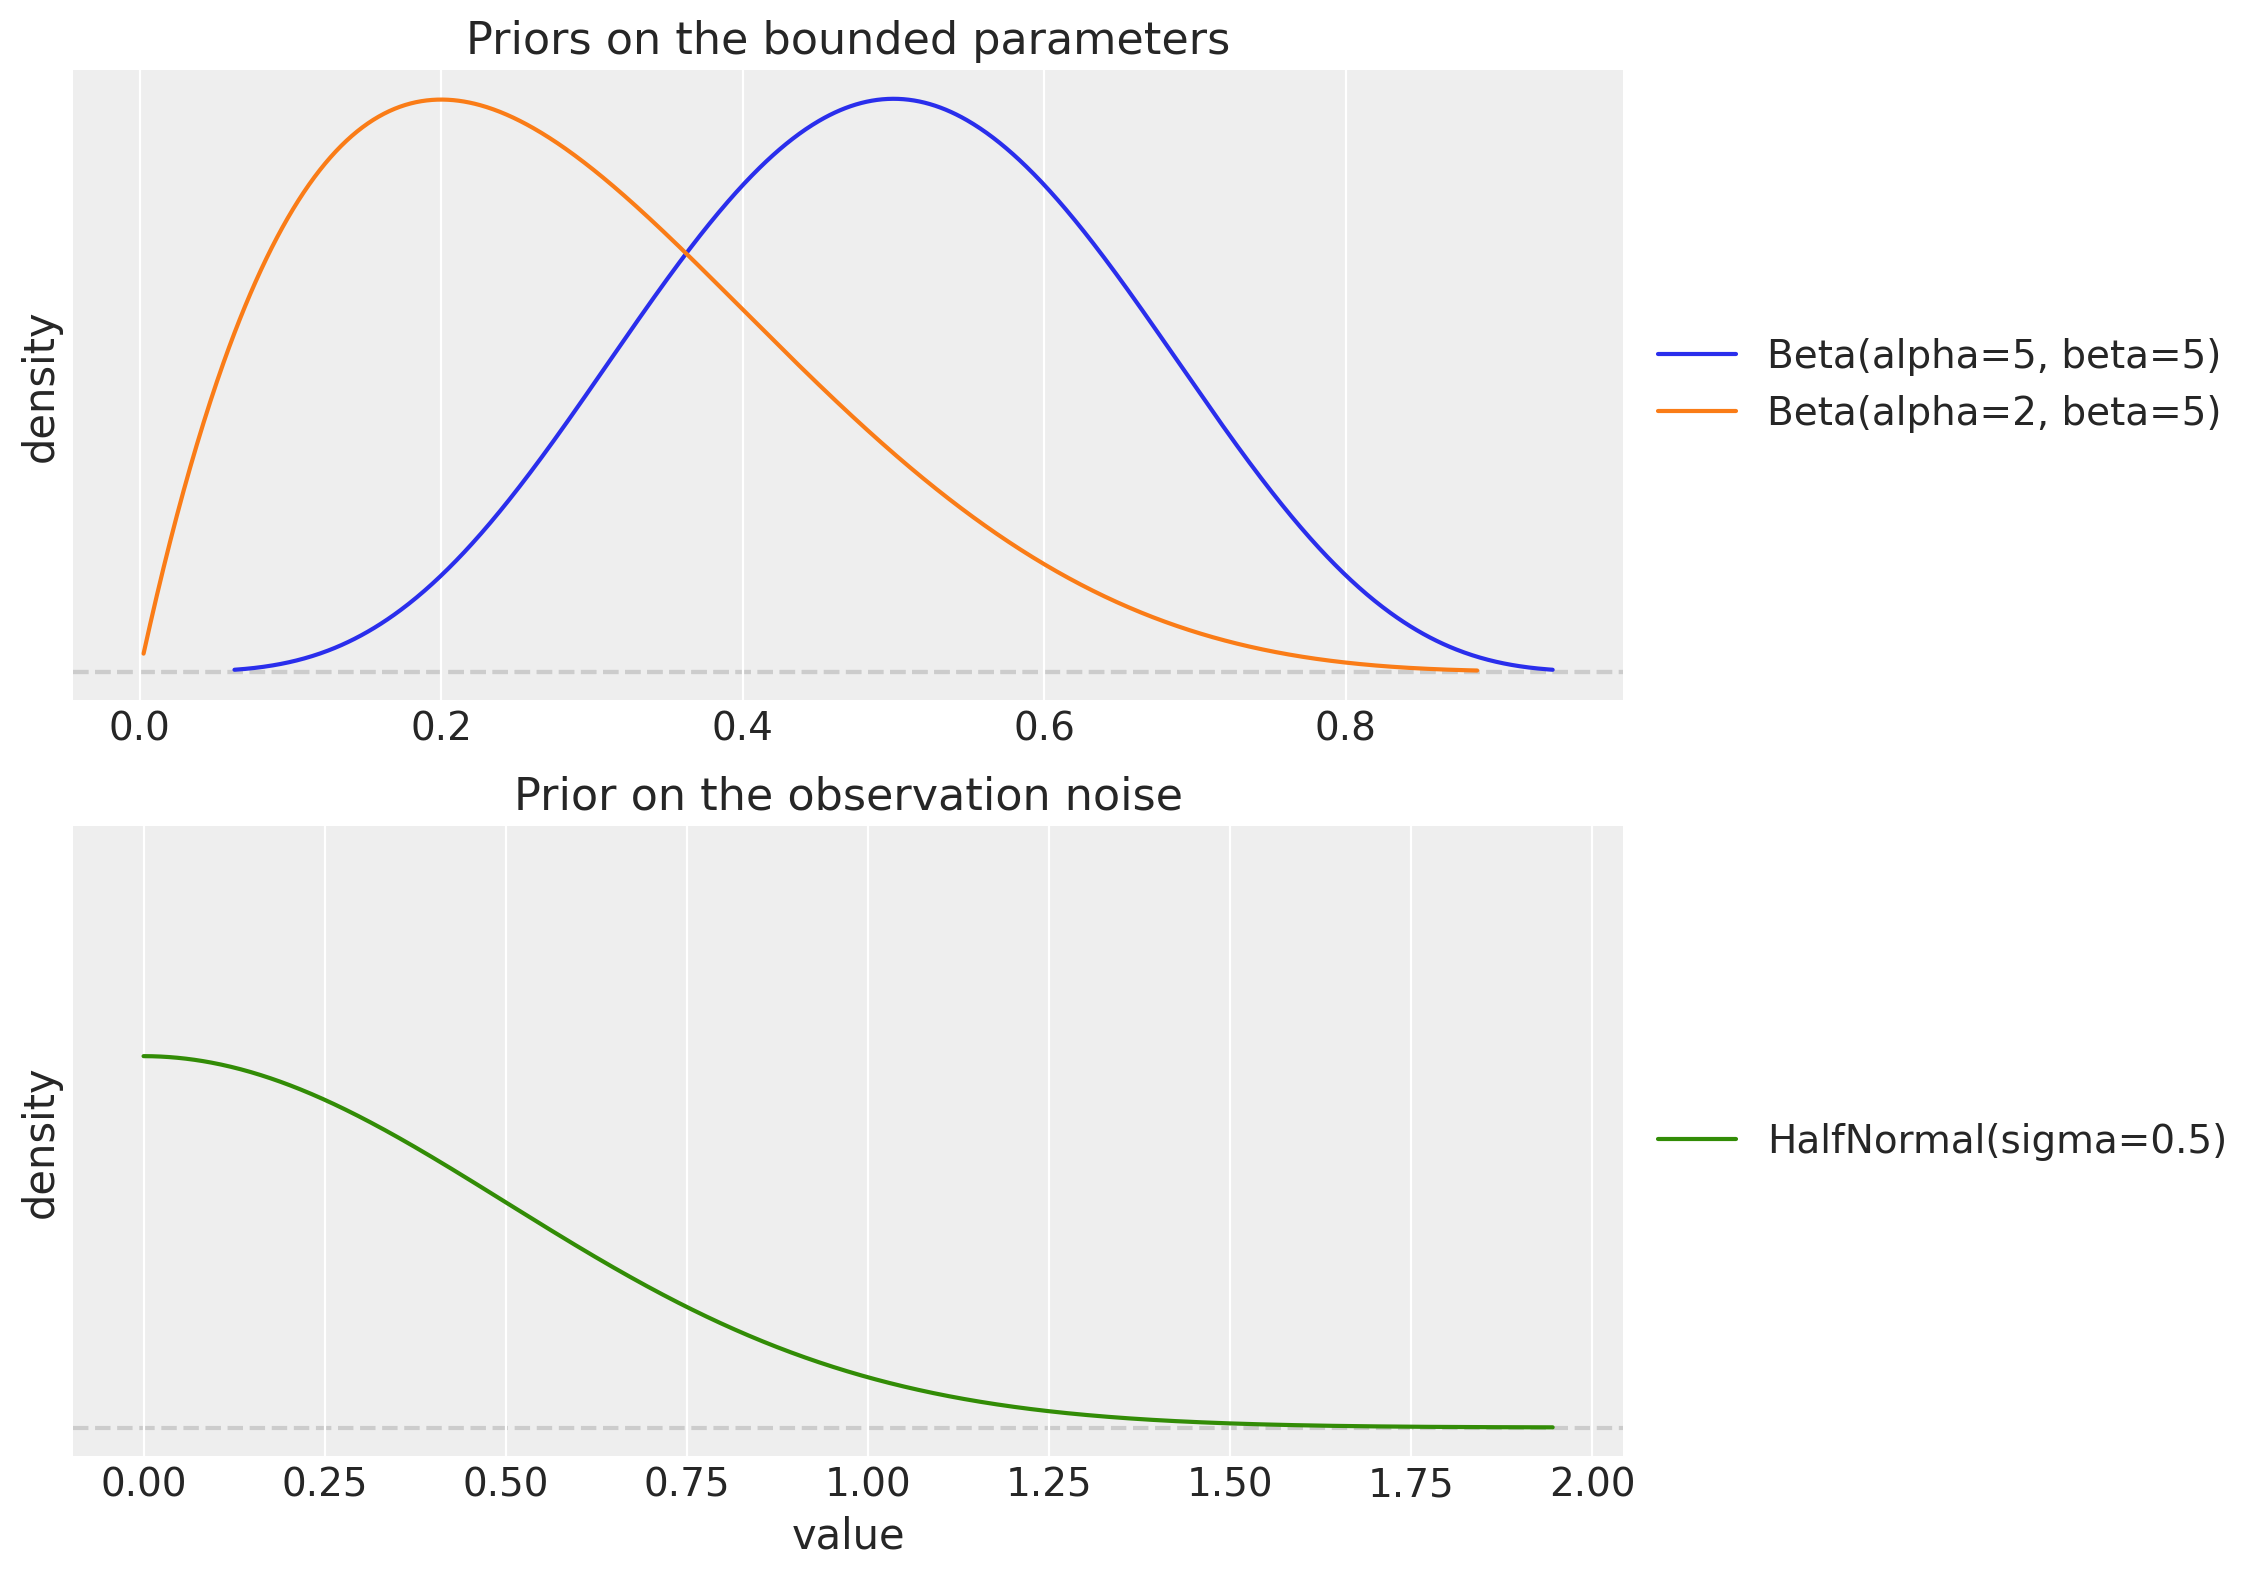

In [6]:
fig, (ax_smoothing, ax_noise) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 9),
    sharex=False,
    sharey=True,
    layout="constrained",
)
pz.Beta(5, 5).plot_pdf(ax=ax_smoothing, color="C0")
pz.Beta(2, 5).plot_pdf(ax=ax_smoothing, color="C1")
ax_smoothing.set(
    title="Priors on the bounded parameters",
    xlabel=None,
    ylabel="density",
)

pz.HalfNormal(0.5).plot_pdf(ax=ax_noise, color="C2")
ax_noise.set(
    title="Prior on the observation noise",
    xlabel="value",
    ylabel="density",
);

## Inference

We fit the model with plain NumPyro: the NUTS sampler through `MCMC`,
running $4$ chains of $2{,}000$ warmup and $2{,}000$ sampling steps each
on the training window. The model is an ordinary NumPyro callable, so
nothing package-specific happens here; `mcmc.get_samples()` returns the
posterior draws as a plain dictionary with the chains flattened
together, which is the format every package driver consumes.

We then export the draws into an ArviZ-schema `xarray.DataTree` with
[`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html):
a single call restores the `(chain, draw)` structure (we pass
`num_chains=4`), samples the in-sample one-step-ahead posterior
predictive from the same draws, and, because we hand it the
*full-horizon* covariates, also runs the forecast and stores it in the
`predictions` group. Everything downstream (diagnostics, trace plots,
the in-sample fit, the forecast, the metrics) reads from this one
object.

In [7]:
rng_key, rng_subkey = random.split(rng_key)
mcmc = MCMC(
    NUTS(exponential_smoothing_ssm),
    num_warmup=2_000,
    num_samples=2_000,
    num_chains=4,
    chain_method="sequential",
    progress_bar=False,
)
mcmc.run(rng_subkey, covariates_train, train_data)
posterior = mcmc.get_samples()

rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    exponential_smoothing_ssm,
    posterior,
    train_data,
    covariates_full,
    num_chains=4,
    posterior_dims={"mu": ["time", "obs_dim"]},
)
tree

<xarray.DataTree>
Group: /
│ Attributes:
│ inference_library: numpyro
│ creation_library: numpyro_forecast
│ sample_dims: ['chain', 'draw']
├── Group: /posterior
│ Dimensions: (chain: 4, draw: 2000, time: 192, obs_dim: 1,
│ seasonality_init_dim_0: 15)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 16kB 0 1 2 3 4 ... 1996 1997 1998 1999
│ * time (time) int64 2kB 0 1 2 3 4 5 ... 187 188 189 190 191
│ * obs_dim (obs_dim) int64 8B 0
│ * seasonality_init_dim_0 (seasonality_init_dim_0) int64 120B 0 1 2 ... 13 14
│ Data variables:
│ level_init (chain, draw) float32 32kB 0.3102 0.4143 ... 0.5364
│ level_smoothing (chain, draw) float32 32kB 0.2118 0.207 ... 0.212
│ mu (chain, draw, time, obs_dim) float32 6MB 0.9767 ....
│ noise (chain, draw) float32 32kB 0.233 0.2251 ... 0.2407
│ phi (chain, draw) float32 32kB 0.3755 0.3285 ... 0.3153
│ seasonality_init (chain, draw, seasonality_init_dim_0) float32 480kB ...
│ seasonality_smoothing (chain, draw) float32 32kB 0.2746 0.1679 ... 0.3157
│ trend_init (chain, draw) float32 32kB 0.09367 ... -0.05799
│ trend_smoothing (chain, draw) float32 32kB 0.5881 0.5905 ... 0.3572
│ Attributes:
│ created_at: 2026-08-26T16:35:47.762252+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /posterior_predictive
│ Dimensions: (chain: 4, draw: 2000, time: 192, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│ * time (time) int64 2kB 0 1 2 3 4 5 6 7 ... 185 186 187 188 189 190 191
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 6MB 0.689 1.007 ... 2.481
│ Attributes:
│ created_at: 2026-08-26T16:35:47.907858+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /observed_data
│ Dimensions: (time: 192, obs_dim: 1)
│ Coordinates:
│ * time (time) int64 2kB 0 1 2 3 4 5 6 7 ... 185 186 187 188 189 190 191
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (time, obs_dim) float32 768B 1.121 1.137 0.6104 ... 2.527 2.841
│ Attributes:
│ created_at: 2026-08-26T16:35:47.908092+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: []
├── Group: /constant_data
│ Dimensions: (time: 192, covariate_dim: 1)
│ Coordinates:
│ * time (time) int64 2kB 0 1 2 3 4 5 6 ... 186 187 188 189 190 191
│ * covariate_dim (covariate_dim) int64 8B 0
│ Data variables:
│ covariates (time, covariate_dim) float32 768B 1.121 1.137 ... 2.841
│ Attributes:
│ created_at: 2026-08-26T16:35:47.908261+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: []
├── Group: /predictions
│ Dimensions: (chain: 4, draw: 2000, time: 48, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│ * time (time) int64 384B 192 193 194 195 196 197 ... 235 236 237 238 239
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 2MB 3.364 3.11 ... 3.689 4.017
│ Attributes:
│ created_at: 2026-08-26T16:35:48.088411+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.0
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
└── Group: /predictions_constant_data
 Dimensions: (time: 48, covariate_dim: 1)
 Coordinates:
 * time (time) int64 384B 192 193 194 195 196 ... 235 236 237 238 239
 * covariate_dim (covariate_dim) int64 8B 0
 Data variables:
 covariates (time, covariate_dim) float32 192B 0.0 0.0 0.0 ... 0.0 0.0
 Attributes:
 created_at: 2026-08-26T16:35:48.088629+00:00
 creation_library: ArviZ
 creation_library_version: 1.3.0
 creation_library_language: Python
 sample_dims: [] xarray.DataTree /posterior (19) Dimensions: chain : 4 draw : 2000 time : 192 obs_dim : 

## Diagnostics

With the chains restored in the tree, ArviZ’s convergence diagnostics
apply directly: $\hat{R}$ and the bulk and tail effective sample sizes
for the scalar parameters.

In [8]:
scalar_vars = [
    "level_smoothing",
    "trend_smoothing",
    "seasonality_smoothing",
    "phi",
    "noise",
    "level_init",
    "trend_init",
]
rhat = az.rhat(tree, var_names=scalar_vars)
ess_bulk = az.ess(tree, var_names=scalar_vars)
ess_tail = az.ess(tree, var_names=scalar_vars, method="tail")
diagnostics = pd.DataFrame(
    {
        "r_hat": [float(rhat[name].item()) for name in scalar_vars],
        "ess_bulk": [float(ess_bulk[name].item()) for name in scalar_vars],
        "ess_tail": [float(ess_tail[name].item()) for name in scalar_vars],
    },
    index=scalar_vars,
)
diagnostics.round({"r_hat": 3, "ess_bulk": 0, "ess_tail": 0})

The $\hat{R}$ values are close to $1$ and the effective sample sizes are
healthy, which indicates that the chains have mixed well. This is the
payoff of the state space parameterization together with the tuned
priors: the posterior geometry is well behaved and the sampler explores
it without trouble. The trace plots below confirm the good mixing.

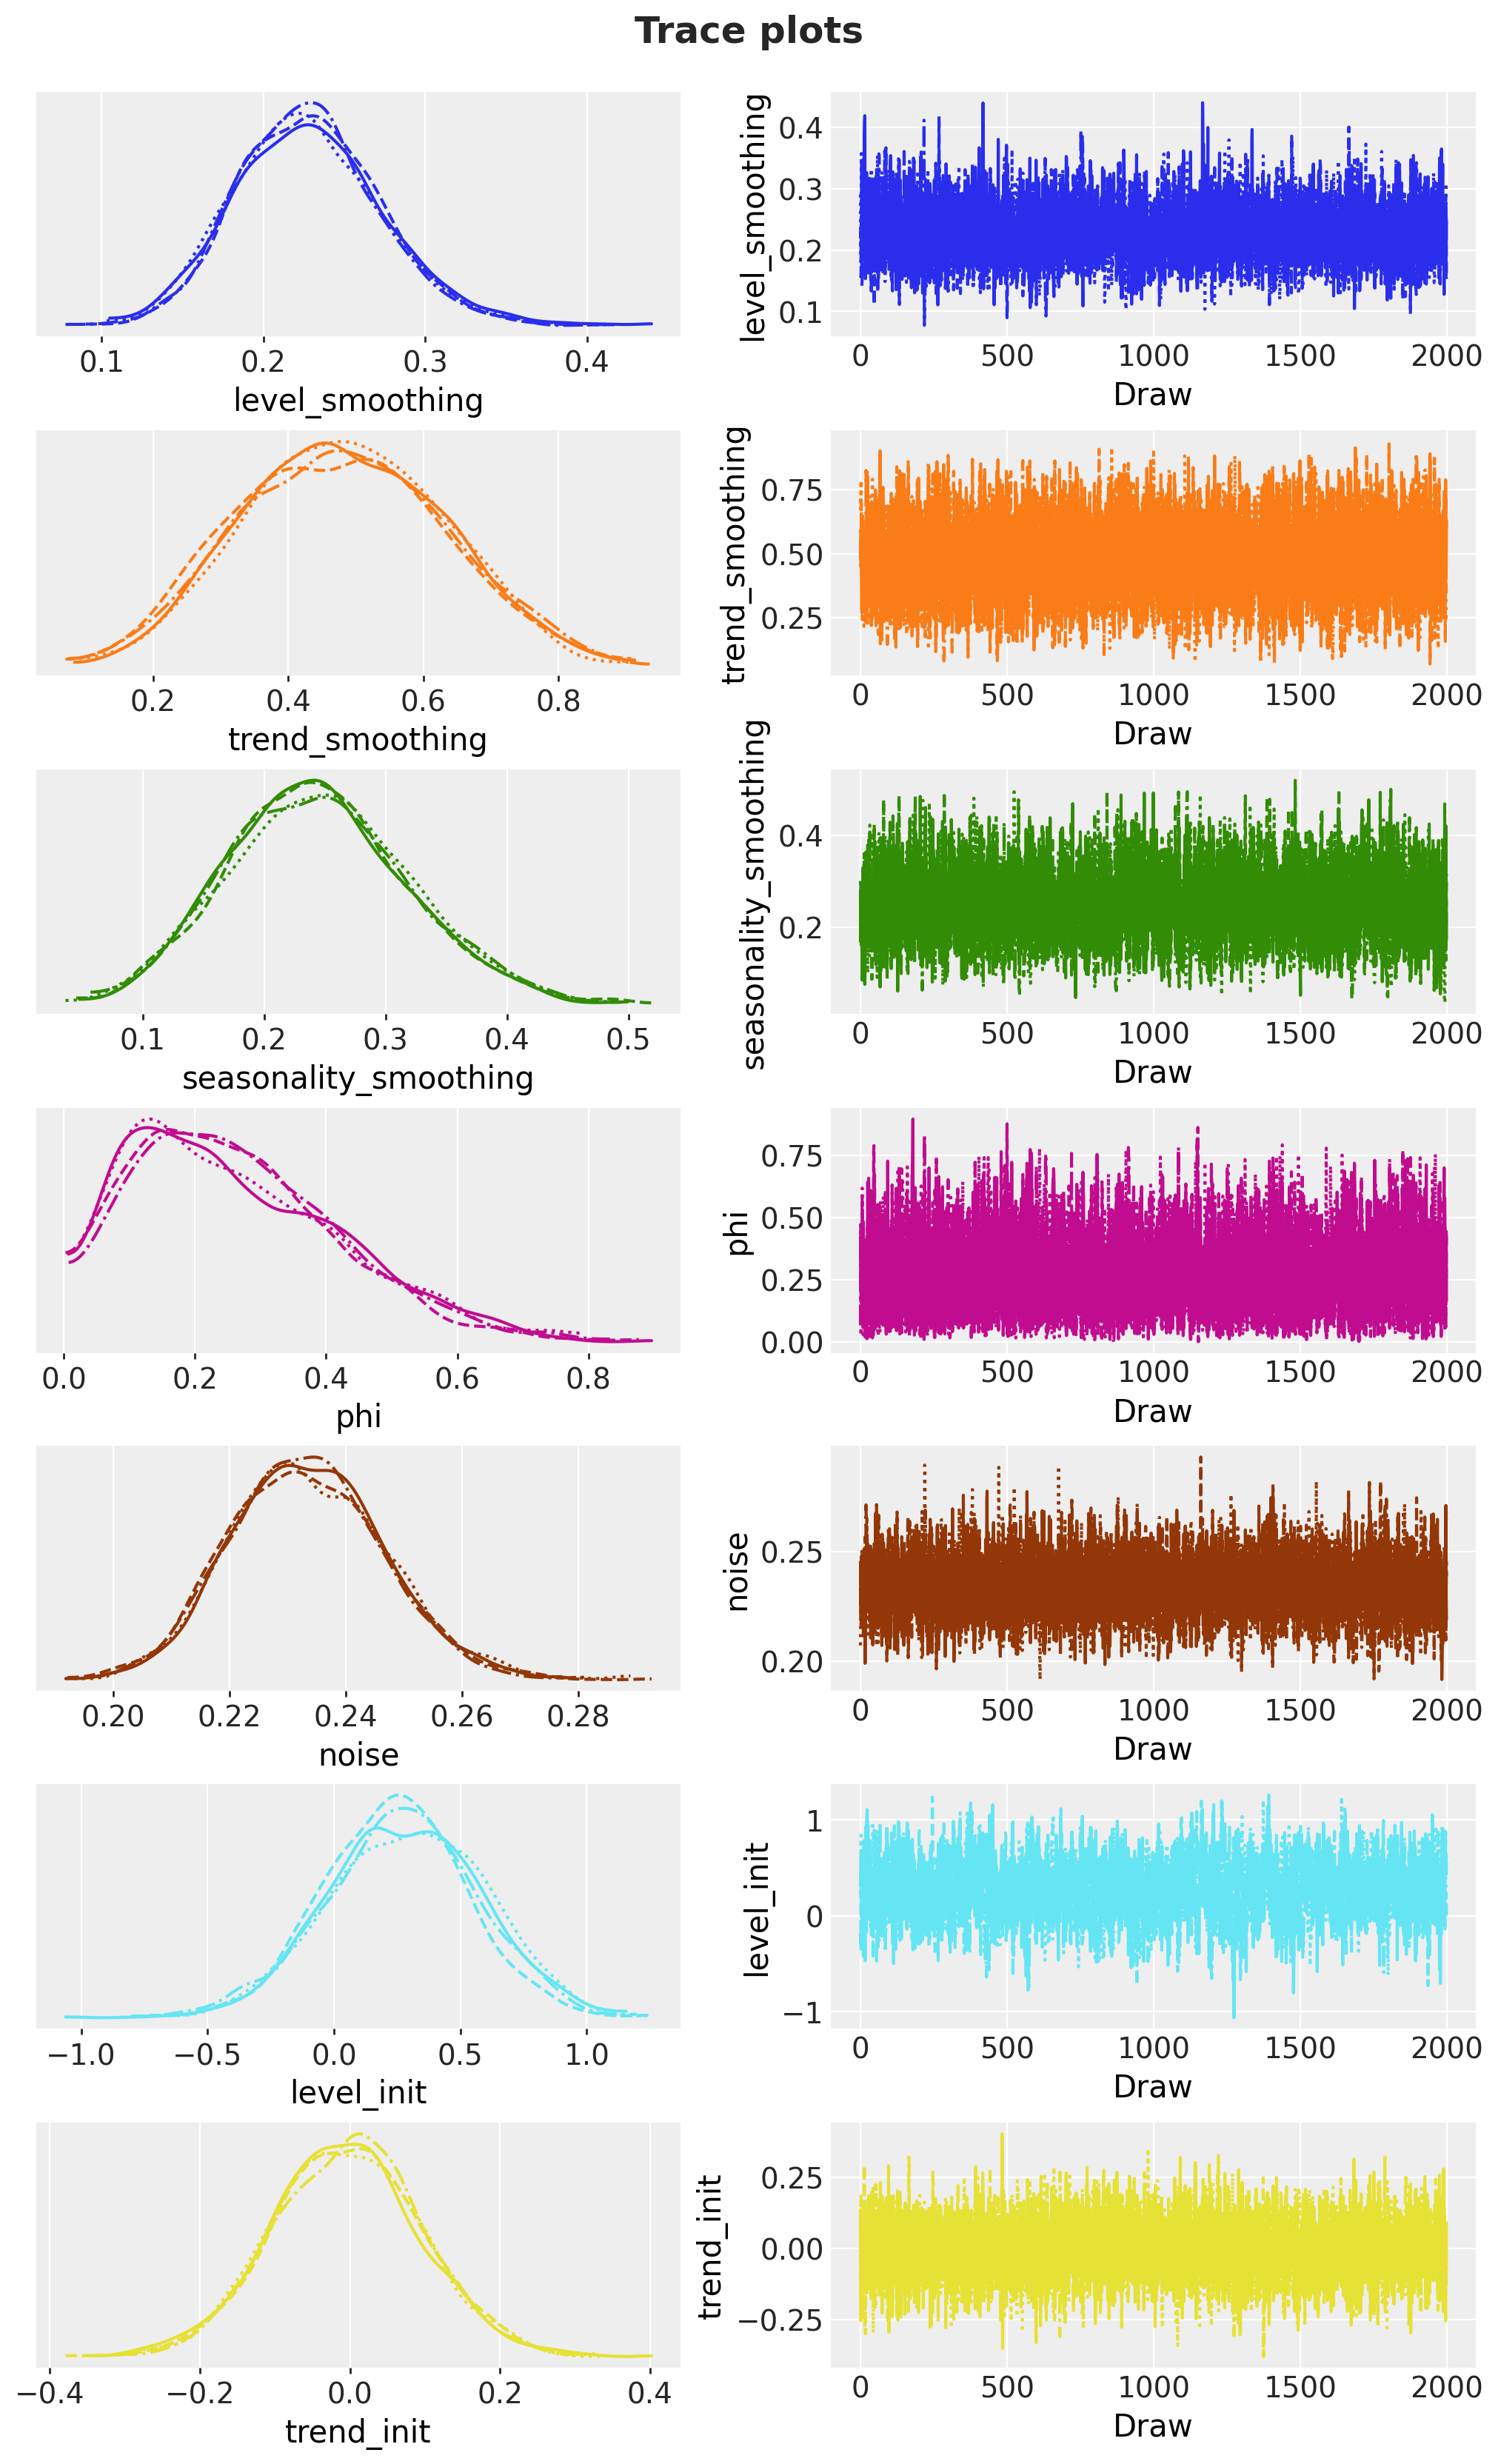

In [9]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=scalar_vars,
    figure_kwargs={"figsize": (10, 16)},
    compact=True,
)
pc_trace.viz["figure"].item().suptitle(
    "Trace plots",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## Forecast

The tree already holds both predictive ensembles, one draw per posterior
sample. The `posterior_predictive` group is the in-sample one-step-ahead
predictive of the `"obs"` site: the fitted mean $\mu_t$ plus observation
noise. The `predictions` group holds the forecast over the test horizon:
for each posterior draw the model replayed the in-sample filter, then
rolled the state forward while sampling fresh innovations. We stack the
`(chain, draw)` dimensions of each into a single sample axis to get the
draws-first layout the plotting and scoring helpers expect. One
consequence worth noting: the bands and the metrics below use all
$8{,}000$ forecast paths, one per posterior draw, rather than a thinned
subset, so the plotted ensemble and the scored ensemble are the same.

In [10]:
def stacked_draws(group: xr.DataTree | xr.DataArray, var: str) -> np.ndarray:
    """Stack a tree variable's ``(chain, draw)`` dims into a leading sample axis.

    Parameters
    ----------
    group
        A tree group holding ``var`` with dims ``(chain, draw, time, obs_dim)``
        (typed as the union ``tree[...]`` returns; a group always arrives here).
    var
        Name of the variable to extract.

    Returns
    -------
    np.ndarray
        The draws with shape ``(sample, time, obs_dim)``.
    """
    return (
        group.dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


in_sample_pp = stacked_draws(tree["posterior_predictive"], "obs")
forecast_draws = stacked_draws(tree["predictions"], "obs")

print(f"in-sample posterior predictive: {in_sample_pp.shape}")
print(f"forecast samples: {forecast_draws.shape}")

in-sample posterior predictive: (8000, 192, 1)
forecast samples: (8000, 48, 1)

We visualize both the in-sample fit and the forecast with `az.plot_lm`,
showing the $50\%$ and $94\%$ HDI bands (packing each ensemble with the
package’s `predictions_to_datatree`). The forecast band (in orange)
clearly fans out as the horizon grows: this is the calibrated
uncertainty that the innovations state space form provides.

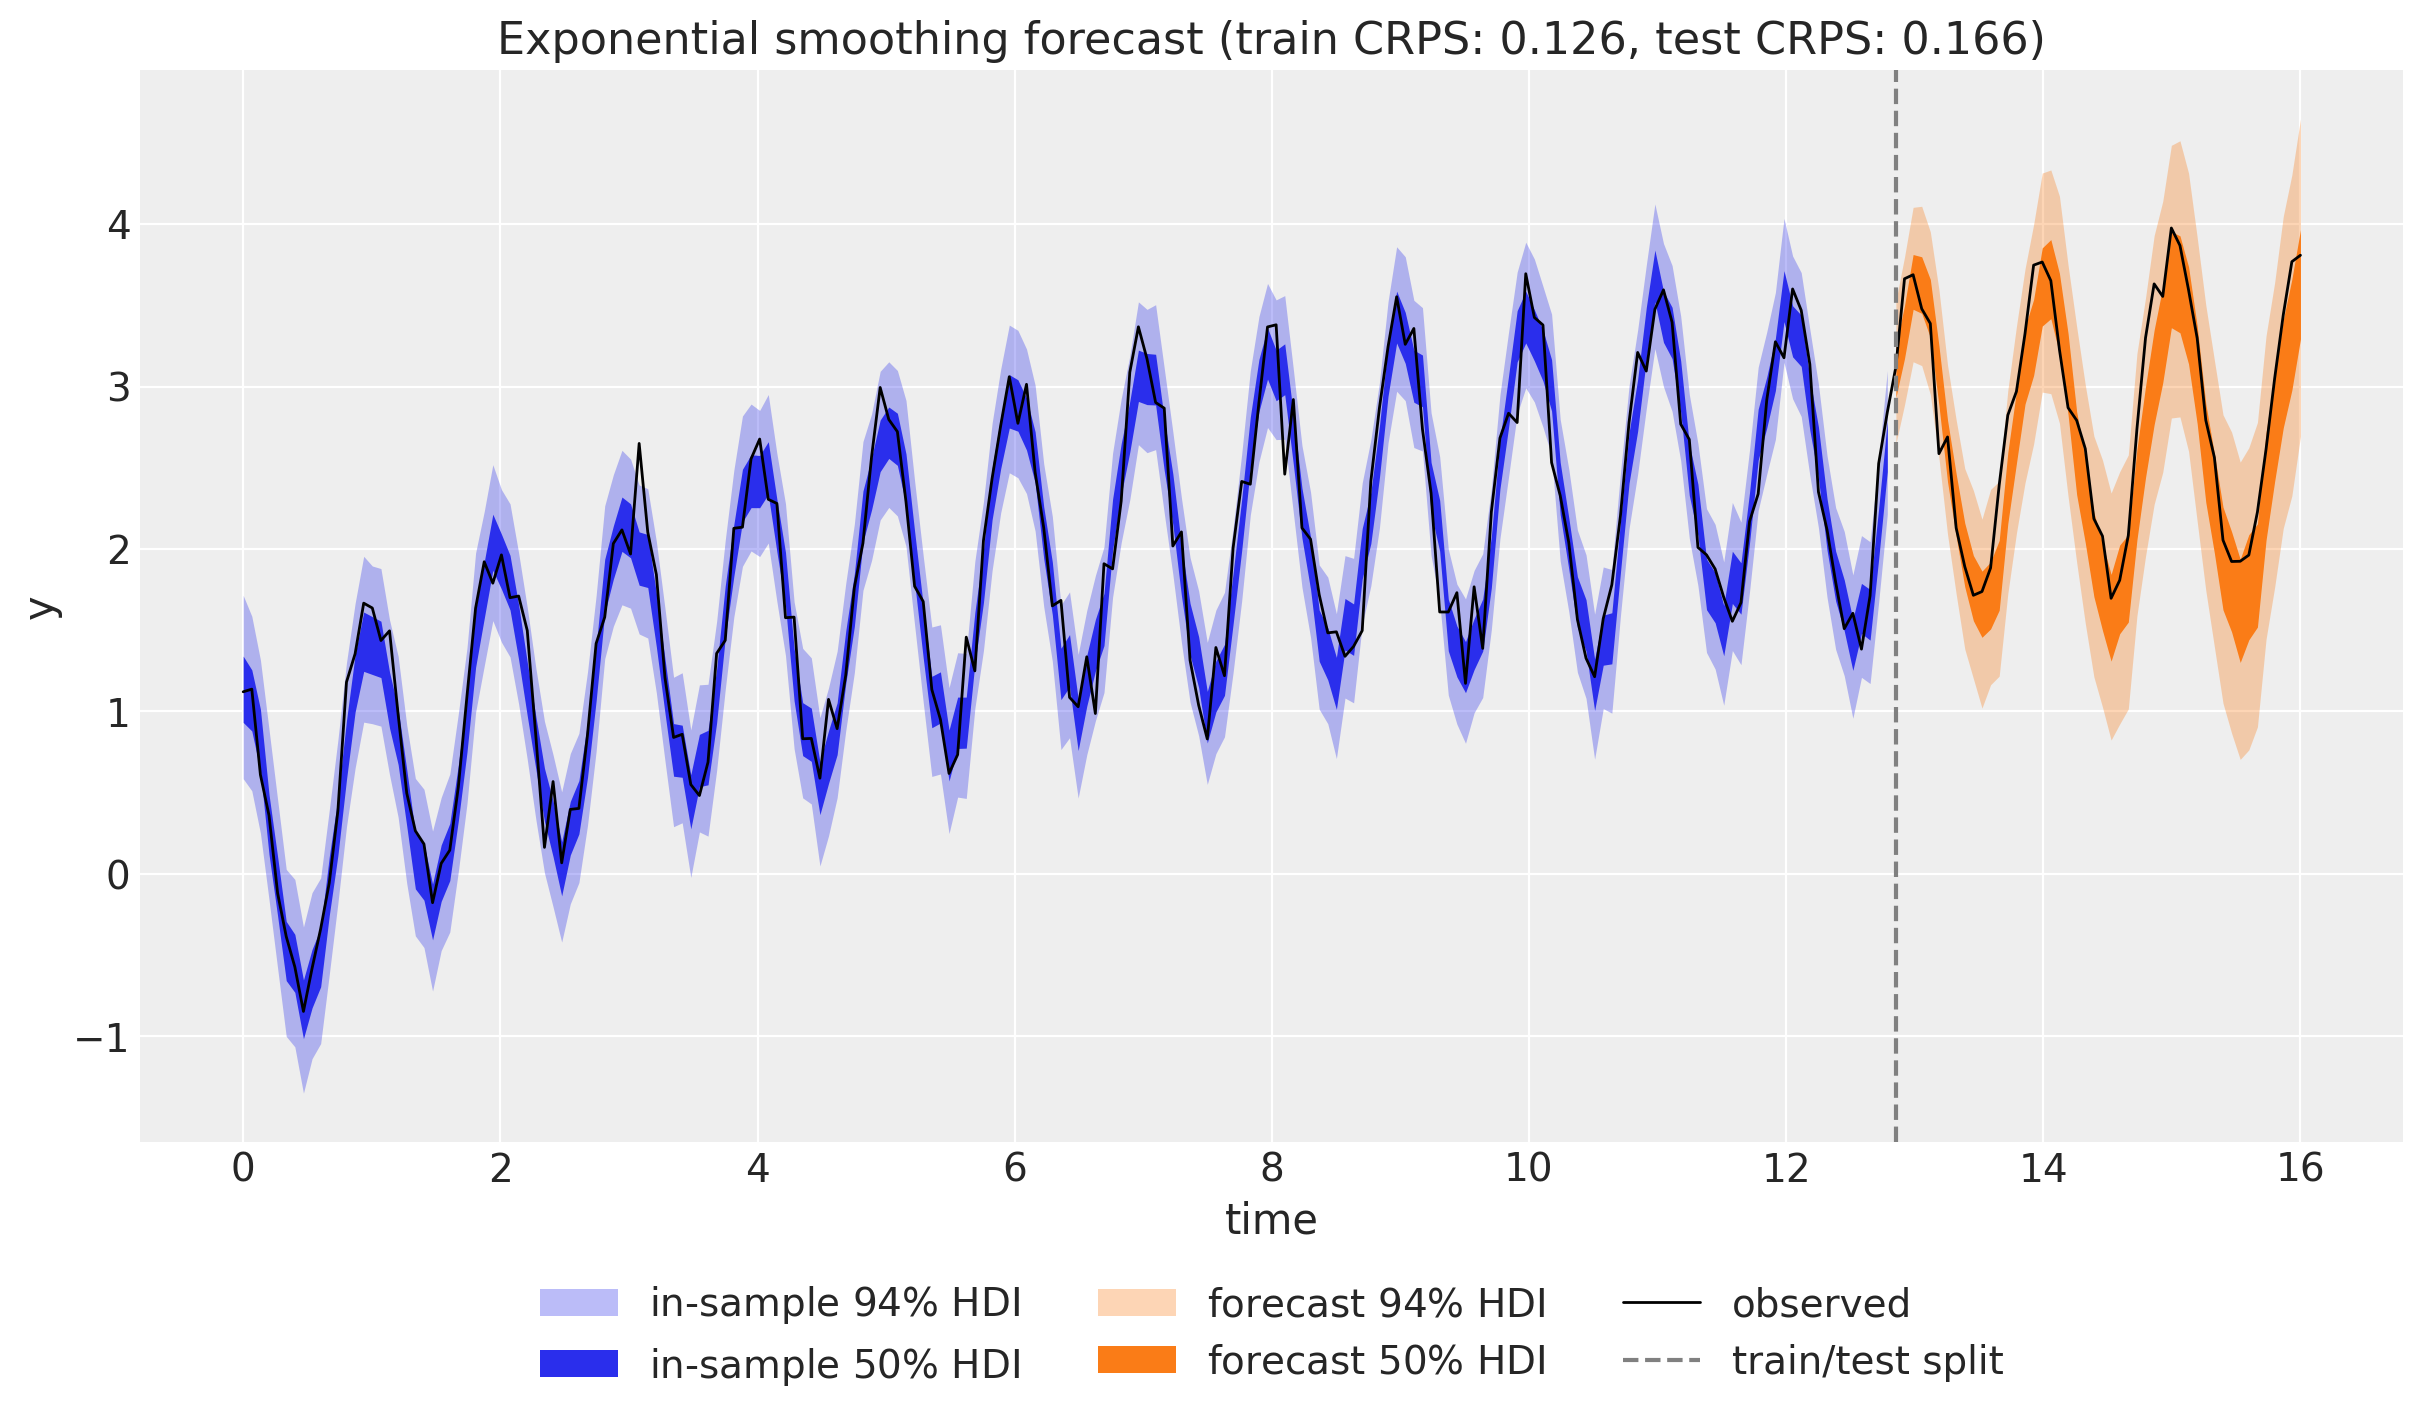

In [11]:
crps_train = eval_crps(in_sample_pp, train_data)
crps_test = eval_crps(forecast_draws, test_data)

hdi_probs = (0.5, 0.94)
pc = az.plot_lm(
    predictions_to_datatree(in_sample_pp, np.asarray(t_train), ["y"], observed=train_data),
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 7)},
)
in_sample_bands = pc.viz["ci_band"]["t"]
band_in_94 = in_sample_bands.sel(prob=0.94).item()
band_in_50 = in_sample_bands.sel(prob=0.5).item()

az.plot_lm(
    predictions_to_datatree(forecast_draws, np.asarray(t_test), ["y"], observed=test_data),
    y="obs",
    x="t",
    plot_dim="time",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
forecast_bands = pc.viz["ci_band"]["t"]
band_fc_94 = forecast_bands.sel(prob=0.94).item()
band_fc_50 = forecast_bands.sel(prob=0.5).item()

ax = pc.viz["figure"].item().axes[0]
band_in_94.set_label(r"in-sample $94\%$ HDI")
band_in_50.set_label(r"in-sample $50\%$ HDI")
band_fc_94.set_label(r"forecast $94\%$ HDI")
band_fc_50.set_label(r"forecast $50\%$ HDI")
(observed_line,) = ax.plot(np.asarray(t), np.asarray(y), color="black", lw=1, label="observed")
split_line = ax.axvline(float(t_test[0]), color="gray", linestyle="--", label="train/test split")
ax.legend(
    handles=[band_in_94, band_in_50, band_fc_94, band_fc_50, observed_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"Exponential smoothing forecast (train CRPS: {crps_train:.3f}, test CRPS: {crps_test:.3f})",
    xlabel="time",
    ylabel="y",
);

## Evaluation

Finally, we score the forecast against the held-out test set with the
package’s evaluation metrics: mean absolute error and root mean squared
error (point-forecast accuracy), the continuous ranked probability score
(a proper score for the whole predictive distribution), and the
empirical coverage of the central $90\%$ interval (calibration).

In [12]:
metrics = {
    "MAE": eval_mae(forecast_draws, test_data),
    "RMSE": eval_rmse(forecast_draws, test_data),
    "CRPS": eval_crps(forecast_draws, test_data),
    "coverage (90%)": eval_coverage(forecast_draws, test_data, alpha=0.9),
}
for name, value in metrics.items():
    print(f"{name:>16}: {value:.4f}")

             MAE: 0.2436
            RMSE: 0.2821
            CRPS: 0.1657
  coverage (90%): 0.9583

The coverage of the central $90\%$ interval sits close to its nominal
level, confirming that the forecast is well calibrated. For a systematic
assessment over multiple origins you would reach for
`numpyro_forecast.backtest`, which refits the model on a moving window
(the [ARMA
example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html)
does exactly that with the same building block); we omit it here because
it retrains the full sampler for every window.

## References

- Hyndman, R. J., & Athanasopoulos, G. (2021). [*Forecasting: Principles
  and Practice*](https://otexts.com/fpp3/), 3rd edition. Chapters on
  exponential smoothing and ETS models.
- Hyndman, R. J., Koehler, A. B., Ord, J. K., & Snyder, R. D. (2008).
  *Forecasting with Exponential Smoothing: The State Space Approach*.
  Springer.
- Orduz, J. [*Exponential Smoothing with NumPyro: State Space
  Form*](https://juanitorduz.github.io/exponential_smoothing_numpyro_ssm/).
- Orduz, J. [*Notes on Exponential Smoothing with
  NumPyro*](https://juanitorduz.github.io/exponential_smoothing_numpyro/).